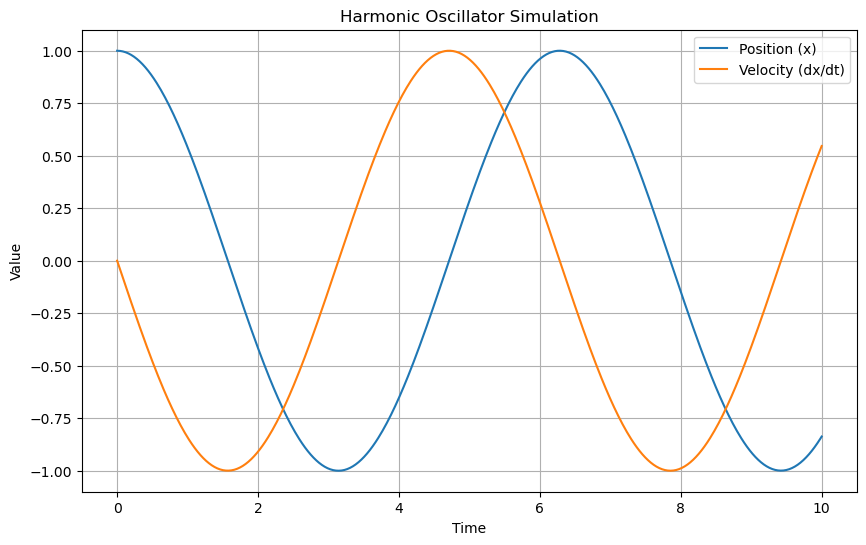

In [1]:
# A test code for simulation code involving time derivatives
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define the ODE system (time derivatives)

def harmonic_oscillator(t, y, k, m):
    """
    Defines the system of ODEs for a harmonic oscillator.
    y[0] represents position (x)
    y[1] represents velocity (dx/dt)
    """
    x, v = y
    dxdt = v
    dvdt = -k/m * x  # F = -kx, F = ma => a = -k/m * x
    return [dxdt, dvdt]

# Simulation parameters
k = 1.0  # Spring constant
m = 1.0  # Mass
initial_position = 1.0
initial_velocity = 0.0
t_span = (0, 10)  # Time span for the simulation
t_eval = np.linspace(*t_span, 500) # Points at which to store the solution

# Initial conditions
y0 = [initial_position, initial_velocity]

# Solve the ODE
solution = solve_ivp(
    harmonic_oscillator,
    t_span,
    y0,
    args=(k, m),
    t_eval=t_eval,
    method='RK45' # Runge-Kutta 45 method
)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(solution.t, solution.y[0], label='Position (x)')
plt.plot(solution.t, solution.y[1], label='Velocity (dx/dt)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Harmonic Oscillator Simulation')
plt.legend()
plt.grid(True)
plt.show()

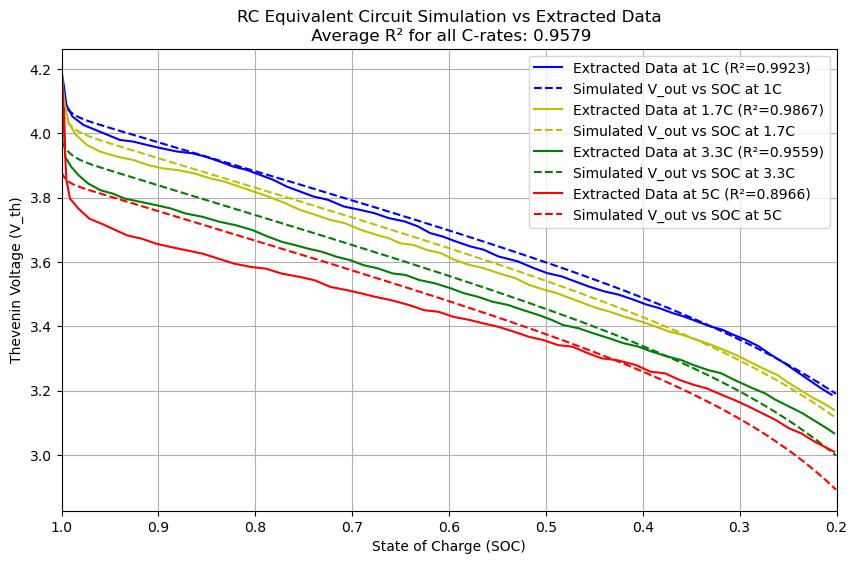

In [19]:
# A test code for simulation code involving time derivatives
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import os.path
import pandas as pd

## Known Parameters of Battery

C_cap = 3.0   # Battery capacity in Ah
C_th  = 2000  # Equivalent capacity in F, fixed for testing
eta = 0.99   # Coulombic efficiency

## the following correction factors are found in Park's work [[park2025RefinedAircooled]]
alpha = 2.6 * 10**-3 # C-Rate correction factor for R_0 based on C-Rate
beta = - 5.0 * 10**-1  # C-Rate correction factor for R_th based on C-Rate

# Define the ODE system (time derivatives)

def RC_equivalent_circuit(t, y, I_batt, T_batt, C_rate):
    """
    Defines the system of ODEs for a RC equivalent circuit
    y[0] represents Voltage thevenin (V)
    y[1] represents State of Charge (SOC)    
    """
    V_th, SOC = y
    R_th = -0.0356 * SOC + 0.0592 # Ohmic resistance as a function of SOC at T_batt=20 oC
    R_th = R_th * np.exp(beta * C_rate)  # C-rate correction for R_th    
    # R_0 = 0.0697 * np.exp(-12.4547 * SOC) + 0.0219 * np.exp(-0.1674 * SOC)  # Ohmic resistance as a function of SOC at T_batt=20 oC
    # V_OC = 3.43 * np.exp(0.1938 * SOC) - 0.5517 * np.exp(-5.0321 * SOC)   # Open circuit voltage as a function of SOC at T_batt=20 oC
    
    dVthdt = -V_th/(R_th*C_th) + I_batt/C_th  # dVth/dt
    dSOCdt = -eta * I_batt/(C_cap*3600)  # dSOC/dt 
    
    return [dVthdt, dSOCdt]

exp_cfg = {
    "1C" : {"C_rate": 1.0, "line_style_calc": "--", "line_color_calc": "b", "line_style_data": "-", "line_color_data": "b"},
    "1.7C" : {"C_rate": 1.7, "line_style_calc": "--", "line_color_calc": "y", "line_style_data": "-", "line_color_data": "y"},
    "3.3C" : {"C_rate": 3.3, "line_style_calc": "--", "line_color_calc": "g", "line_style_data": "-", "line_color_data": "g"},
    "5C" : {"C_rate": 5.0, "line_style_calc": "--", "line_color_calc": "r", "line_style_data": "-", "line_color_data": "r"},    
}

# Read the data saved in datafile
datafile = os.path.join(os.path.curdir, "data", "HP02R0301A2 data_SOC vs Vth_18650-30Q_extracted_Fig_03_park2025RefinedAircooled_xin_20251208.xlsx")

# a dict to collect results for different C-rates
results = {}
r_squared_all = 0.0 # the average R-squared for all C-rates

for C_rate_label in exp_cfg.keys():
    
    C_rate = exp_cfg[C_rate_label]["C_rate"]
    # Simulation parameters
    SOC_init = 1.0  # starting State of Charge (fully charged)
    Vth_init = 0.0  # initial Thevenin voltage    
    I_batt = C_cap * C_rate  # Constant discharge current in A, equal to 1C rate
    T_batt = 20.0   # Battery temperature in Celsius
    end_time = C_cap / I_batt * 3600  # in seconds
    t_span = (0, end_time)  # Time span for the simulation
    t_eval = np.linspace(*t_span, 500) # Points at which to store the solution

    # Initial conditions
    y0 = [Vth_init, SOC_init]

    # Solve the ODE
    solution = solve_ivp(
        RC_equivalent_circuit,
        t_span,
        y0,
        args=(I_batt, T_batt, C_rate),
        t_eval=t_eval,
        method='RK45' # Runge-Kutta 45 method
    )

    # Calculate terminal voltage over time

    V_out_calc = []    

    for i in range(len(solution.t)):
        SOC_calc = solution.y[1][i]
        V_th = solution.y[0][i]
        
        R_th = -0.0356 * SOC_calc + 0.0592 # Ohmic resistance as a function of SOC at T_batt=20 oC
        R_th = R_th * np.exp(beta * C_rate)  # C-rate correction for R_th
        
        R_0 = 0.0697 * np.exp(-12.4547 * SOC_calc) + 0.0219 * np.exp(-0.1674 * SOC_calc)  # Ohmic resistance as a function of SOC at T_batt=20 oC
        R_0 = R_0 * (1 + alpha * C_rate)  # C-rate correction for R_0
        
        V_OC = 3.43 * np.exp(0.1938 * SOC_calc) - 0.5517 * np.exp(-5.0321 * SOC_calc)   # Open circuit voltage as a function of SOC at T_batt=20 oC
        V_out_calc.append(V_OC - I_batt * R_0 - V_th)        

    V_out_calc = np.array(V_out_calc)
    results[C_rate_label] = { "SOC_calc": solution.y[1], "V_th_calc": solution.y[0], "V_out_calc": V_out_calc }
    
    if os.path.isfile(datafile):
        df = pd.read_excel(datafile, sheet_name=C_rate_label)
        SOC_data = df['SOC'].to_numpy()[::-1]  # Reverse the SOC data to match discharge direction
        V_out_data = df['V_out'].to_numpy()[::-1]  # Reverse the Vth data to match discharge direction
    
    results[C_rate_label]["SOC_data"] = SOC_data
    results[C_rate_label]["V_out_data"] = V_out_data
    
    # Calculate R-squared between the data and the calculated V_out
    # Interpolate calculated V_out to the SOC points of the data for fair comparison
    V_out_calc_interp = np.interp(SOC_data, results[C_rate_label]["SOC_calc"][::-1], results[C_rate_label]["V_out_calc"][::-1])
    
    ss_res = np.sum((V_out_data - V_out_calc_interp) ** 2) 
    ss_tot = np.sum((V_out_data - np.mean(V_out_data)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    results[C_rate_label]["R_squared"] = r_squared
    r_squared_all += r_squared

r_squared_all /= len(exp_cfg)

# Plot the results, Thevenin voltage over SOC

plt.figure(figsize=(10, 6))

for C_rate_label in exp_cfg.keys():
    SOC_data = results[C_rate_label]["SOC_data"]
    V_out_data = results[C_rate_label]["V_out_data"]    
    
    SOC_calc = results[C_rate_label]["SOC_calc"]
    # find the index for SOC=0.2 to limit the plot range
    idx_limit_calc = np.where(SOC_calc >= 0.2)[0][-1] + 1
    SOC_calc = SOC_calc[:idx_limit_calc]
    V_out_calc = results[C_rate_label]["V_out_calc"][:idx_limit_calc]
    
    plt.plot(SOC_data, V_out_data, exp_cfg[C_rate_label]["line_style_data"] + exp_cfg[C_rate_label]["line_color_data"], label='Extracted Data at ' + C_rate_label + f' (R²={results[C_rate_label]["R_squared"]:.4f})')
    plt.plot(SOC_calc, V_out_calc, exp_cfg[C_rate_label]["line_style_calc"] + exp_cfg[C_rate_label]["line_color_calc"], label='Simulated V_out vs SOC at ' + C_rate_label)

# ristrict x-axis to SOC from 0.2 to 1.0
plt.xlim(1.0, 0.2) # reverse x-axis, too

plt.xlabel('State of Charge (SOC)')
plt.ylabel('Thevenin Voltage (V_th)')   
plt.title('RC Equivalent Circuit Simulation vs Extracted Data\n Average R² for all C-rates: {:.4f}'.format(r_squared_all))
plt.legend()
plt.grid(True)
plt.show()

